In [1]:
# =============================================================================
# DKTC 위협 대화 분류 — 규칙 기반 후처리(Logit Adjustment) 분석 v2
#
# 근거: dktc_model_improvement_runbook_2026-03-17.md §8.2
#
# v1 → v2 핵심 변경 (코드 리뷰 반영):
#   [수정1] 타겟 혼동축에서만 개입 — top1/top2가 사전 정의된
#           혼동 쌍일 때만 보정 진입
#   [수정2] 매칭 클래스가 현재 top2 안에 있을 때만 boost —
#           무관한 클래스에 boost 방지
#   [수정3] 정규식 축소 — precision 우선, 넓은 패턴 제거
#   [수정4] best 파라미터를 validation 하나에서 확정하지 않음 —
#           ablation 결과는 참고용, 최종 확정은 CV 또는 제출 비교로
#
# 추가 수정:
#   - margin threshold와 boost의 스케일 불일치 문제 대응:
#     boost를 확률 공간이 아닌 'logit gap 비율'로 정규화
#   - coverage 지표 개선: 정답 클래스 boost가 오답 클래스 boost보다
#     우세한지를 측정하는 'net boost advantage' 도입
#   - 변경 로그의 '무관' 주석 수정 (전/후 모두 맞는 경우는 불가)
#
# 타겟 혼동축 (런북 §4.4, §5.4 기준):
#   - 협박(0) ↔ 갈취(1)
#   - 기타괴롭힘(3) ↔ 갈취(1)
#   - 직장내괴롭힘(2) ↔ 기타괴롭힘(3)
#
# 환경: Docker (py-gpu-env), RTX 5060 Ti 16GB, Python 3.10
# =============================================================================
 

In [2]:
# ============================================================================
# 00. 환경 설정 및 최적화
# ============================================================================
import sys, site, os
print("sys.executable =", sys.executable)
print("sys.prefix     =", sys.prefix)
print("site-packages  =", site.getsitepackages())
 
import transformers, datasets, evaluate, huggingface_hub, accelerate
print("transformers:", transformers.__version__)
print("datasets:", datasets.__version__)
print("evaluate:", evaluate.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("accelerate:", accelerate.__version__)
 
 
# %%
import os, time, gc, warnings, json, re
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
 
# 재현성
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
 
from datasets import Dataset, DatasetDict
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from collections import Counter
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)
 
# --- CPU / GPU 최적화 ---
CPU_COUNT = os.cpu_count() or 4
CPU_THREADS = max(1, CPU_COUNT // 2)
 
os.environ["OMP_NUM_THREADS"] = str(CPU_THREADS)
os.environ["MKL_NUM_THREADS"] = str(CPU_THREADS)
os.environ["TOKENIZERS_PARALLELISM"] = "true"
 
torch.set_num_threads(CPU_THREADS)
try:
    torch.set_num_interop_threads(max(1, min(4, CPU_THREADS // 2)))
except RuntimeError:
    pass
 
USE_CUDA = torch.cuda.is_available()
DEVICE = "cuda" if USE_CUDA else "cpu"
 
if USE_CUDA:
    torch.set_float32_matmul_precision("high")
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
 
print("=" * 70)
print(f"PyTorch              : {torch.__version__}")
print(f"CUDA available       : {USE_CUDA}")
print(f"Device               : {DEVICE}")
print(f"CPU count            : {CPU_COUNT}")
print(f"CPU threads          : {CPU_THREADS}")
if USE_CUDA:
    props = torch.cuda.get_device_properties(0)
    free_mem, total_mem = torch.cuda.memory.mem_get_info(0)

    print(f"GPU name             : {props.name}")
    print(f"GPU count            : {torch.cuda.device_count()}")
    print(f"GPU memory(total)    : {props.total_memory / (1024**3):.2f} GB")
    print(f"GPU memory(free)     : {free_mem / (1024**3):.2f} GB")
print("=" * 70)

sys.executable = /usr/bin/python3
sys.prefix     = /usr
site-packages  = ['/usr/local/lib/python3.10/dist-packages', '/usr/lib/python3/dist-packages', '/usr/lib/python3.10/dist-packages']


/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


transformers: 5.3.0
datasets: 4.8.2
evaluate: 0.4.6
huggingface_hub: 1.7.1
accelerate: 1.13.0
PyTorch              : 2.10.0+cu128
CUDA available       : True
Device               : cuda
CPU count            : 20
CPU threads          : 10
GPU name             : NVIDIA GeForce RTX 5060 Ti
GPU count            : 1
GPU memory(total)    : 15.93 GB
GPU memory(free)     : 14.80 GB


In [3]:
# ============================================================================
# 01. 데이터 로드 + 토크나이징
# ============================================================================
MODEL_NAME = "klue/roberta-base"     # 한국어 RoBERTa (111M params)
MAX_LENGTH = 512                     # 97% 커버리지 (전처리 품질 리포트 기준)
NUM_LABELS = 5                       # 협박(0), 갈취(1), 직장내괴롭힘(2), 기타괴롭힘(3), 일반대화(4)
 
LABEL_NAMES = ["협박", "갈취", "직장내괴롭힘", "기타괴롭힘", "일반대화"]
LABEL2ID = {name: idx for idx, name in enumerate(LABEL_NAMES)}
 
# --- 전처리된 CSV 로드 ---
train_df = pd.read_csv("data/train_processed_260317_n_1000.csv")
val_df = pd.read_csv("data/val_processed_260317_n_1000.csv")
 
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Classes: {NUM_LABELS}")
print(f"\n검증 클래스 분포:")
print(val_df["label_name"].value_counts().to_string())
 
# --- 토크나이저 ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
 
# --- Hugging Face Dataset 변환 ---
raw_datasets = DatasetDict({
    "train":      Dataset.from_pandas(train_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df[["text", "label"]].rename(columns={"label": "labels"}).reset_index(drop=True)),
})
 
def preprocess_function(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH, padding=False)
 
tokenized_datasets = raw_datasets.map(
    preprocess_function, batched=True, batch_size=1000,
    num_proc=max(1, min(8, CPU_THREADS)),
    remove_columns=["text"], desc="Tokenizing"
)
tokenized_datasets.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
 
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    pad_to_multiple_of=8 if USE_CUDA else None,
    return_tensors="pt",
)
 
# --- 원본 텍스트 배열 (규칙 적용에 필요) ---
val_texts = val_df["text"].values
val_true_labels = val_df["label"].values
 
print(f"\n토크나이징 완료 — 원본 텍스트 {len(val_texts)}개 보존")

Train: 3942, Val: 969, Classes: 5

검증 클래스 분포:
label_name
기타 괴롭힘 대화      202
일반 대화          200
갈취 대화          195
직장 내 괴롭힘 대화    194
협박 대화          178


Setting TOKENIZERS_PARALLELISM=false for forked processes.
Tokenizing (num_proc=8): 100%|██████████| 3942/3942 [00:00<00:00, 7671.42 examples/s] 
Setting TOKENIZERS_PARALLELISM=false for forked processes.
Tokenizing (num_proc=8): 100%|██████████| 969/969 [00:00<00:00, 2957.43 examples/s]


토크나이징 완료 — 원본 텍스트 969개 보존


In [4]:
# ============================================================================
# 02. 모델 로드 + Raw Logit 추출
# ============================================================================
CHECKPOINT_PATH = "./results_dktc_focal_epoch_5/checkpoint-741"   # ← 실제 경로로 수정
 
import glob
ckpt_candidates = sorted(glob.glob(os.path.join(CHECKPOINT_PATH, "checkpoint-*")))
if ckpt_candidates:
    model_path = ckpt_candidates[-1]
    print(f"체크포인트 발견: {model_path}")
else:
    model_path = CHECKPOINT_PATH
    print(f"직접 경로 사용: {model_path}")
 
model = AutoModelForSequenceClassification.from_pretrained(
    model_path, num_labels=NUM_LABELS
)
model.eval()
if USE_CUDA:
    model = model.to(DEVICE)
 
# --- Trainer로 raw logit 추출 ---
import evaluate as ev
acc_metric = ev.load("accuracy")
f1_metric  = ev.load("f1")
 
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro":    f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
        "f1_weighted": f1_metric.compute(predictions=preds, references=labels, average="weighted")["f1"],
    }
 
trainer = Trainer(
    model=model,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)
 
print("\nValidation 추론 시작...")
val_result = trainer.predict(tokenized_datasets["validation"])
 
# raw_logits: shape (N, 5) — softmax 전
raw_logits = val_result.predictions
val_labels = val_result.label_ids
 
# --- sanity check ---
preds_from_logits = np.argmax(raw_logits, axis=-1)
probs = torch.softmax(torch.tensor(raw_logits, dtype=torch.float32), dim=-1).numpy()
preds_from_probs = np.argmax(probs, axis=-1)
assert np.array_equal(preds_from_logits, preds_from_probs), \
    "FATAL: argmax(logits) != argmax(softmax(logits))"
 
# --- 기본 성능 (후처리 전) ---
baseline_preds = preds_from_logits.copy()
baseline_acc = np.mean(baseline_preds == val_labels)
baseline_f1_macro = f1_score(val_labels, baseline_preds, average="macro")
baseline_f1_weighted = f1_score(val_labels, baseline_preds, average="weighted")
 
print(f"\n후처리 전 성능 (모델 원본):")
print(f"  Accuracy      : {baseline_acc:.4f}")
print(f"  Macro F1      : {baseline_f1_macro:.4f}")
print(f"  Weighted F1   : {baseline_f1_weighted:.4f}")
print(f"  오분류 건수    : {(baseline_preds != val_labels).sum()} / {len(val_labels)}")
print(f"\nLogit shape: {raw_logits.shape}")
print(f"Prob 합계 검증 (첫 5개): {probs[:5].sum(axis=1)}")
 
# --- logit gap 통계 (boost 스케일 설정 근거) ---
# [수정2 근거] boost 크기를 결정하려면 실제 logit 스케일을 알아야 함
sorted_logits = np.sort(raw_logits, axis=-1)[:, ::-1]
logit_gaps = sorted_logits[:, 0] - sorted_logits[:, 1]   # top1 - top2 in logit space
print(f"\nLogit gap (top1-top2) 통계:")
print(f"  mean   : {logit_gaps.mean():.3f}")
print(f"  median : {np.median(logit_gaps):.3f}")
print(f"  std    : {logit_gaps.std():.3f}")
print(f"  p10    : {np.percentile(logit_gaps, 10):.3f}")
print(f"  p25    : {np.percentile(logit_gaps, 25):.3f}")
 
# --- 메모리 해제 ---
del model, trainer
gc.collect()
if USE_CUDA:
    torch.cuda.empty_cache()
print("\nLogit 추출 완료 — 모델 메모리 해제")

직접 경로 사용: ./results_dktc_focal_epoch_5/checkpoint-741


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2225.15it/s]



Validation 추론 시작...



후처리 전 성능 (모델 원본):
  Accuracy      : 0.9298
  Macro F1      : 0.9301
  Weighted F1   : 0.9302
  오분류 건수    : 68 / 969

Logit shape: (969, 5)
Prob 합계 검증 (첫 5개): [1.         1.         0.99999994 1.0000001  0.99999994]

Logit gap (top1-top2) 통계:
  mean   : 3.136
  median : 3.262
  std    : 1.121
  p10    : 1.458
  p25    : 2.573

Logit 추출 완료 — 모델 메모리 해제


In [5]:
# ============================================================================
# 03. 타겟 혼동축 정의 + 경계 샘플 분석
# ============================================================================
# [수정1 핵심] 보정 대상을 타겟 혼동축에만 한정한다.
# 런북 §4.4, §5.4에서 확인된 혼동축만 등록.
#
# frozenset을 사용하는 이유:
#   - 협박→갈취 오분류와 갈취→협박 오분류는 같은 축이다
#   - frozenset({0,1})으로 양방향을 하나로 표현
 
TARGET_CONFUSION_AXES = {
    frozenset({0, 1}),   # 협박 ↔ 갈취
    frozenset({1, 3}),   # 갈취 ↔ 기타괴롭힘
    frozenset({2, 3}),   # 직장내괴롭힘 ↔ 기타괴롭힘
}
 
# 보조 혼동축 (런북에서 덜 심각하지만 존재)
# 필요 시 추가 가능. 현재는 핵심 3개만 사용.
# frozenset({0, 3}),  # 협박 ↔ 기타괴롭힘
 
print("타겟 혼동축:")
for axis in TARGET_CONFUSION_AXES:
    ids = sorted(axis)
    print(f"  {LABEL_NAMES[ids[0]]} ↔ {LABEL_NAMES[ids[1]]}")
 
# --- margin 분포 ---
sorted_probs = np.sort(probs, axis=-1)[:, ::-1]
margins = sorted_probs[:, 0] - sorted_probs[:, 1]
 
print(f"\nMargin 분포 통계:")
print(f"  mean    : {margins.mean():.4f}")
print(f"  median  : {np.median(margins):.4f}")
print(f"  std     : {margins.std():.4f}")
 
# --- 타겟 혼동축 해당 여부별 분석 ---
top2_classes = np.argsort(probs, axis=-1)[:, -2:]   # (N, 2): [2nd, 1st]
top2_sets = [frozenset(row) for row in top2_classes]
 
on_target_mask = np.array([s in TARGET_CONFUSION_AXES for s in top2_sets])
 
ANALYSIS_THRESHOLD = 0.20
boundary_mask = margins < ANALYSIS_THRESHOLD
 
# 4분면 분석: margin 크기 × 혼동축 여부
both_mask = boundary_mask & on_target_mask     # 경계 + 혼동축 = 보정 대상
boundary_only = boundary_mask & ~on_target_mask # 경계이지만 혼동축 아님
target_only = ~boundary_mask & on_target_mask   # 혼동축이지만 마진 큼
 
print(f"\n4분면 분석 (threshold={ANALYSIS_THRESHOLD}):")
print(f"  경계 + 타겟 혼동축 (= 보정 대상) : {both_mask.sum():4d}건 "
      f"(오분류 {(baseline_preds[both_mask] != val_labels[both_mask]).sum()}건)")
print(f"  경계 + 비타겟                   : {boundary_only.sum():4d}건 "
      f"(오분류 {(baseline_preds[boundary_only] != val_labels[boundary_only]).sum()}건)")
print(f"  비경계 + 타겟 혼동축            : {target_only.sum():4d}건 "
      f"(오분류 {(baseline_preds[target_only] != val_labels[target_only]).sum()}건)")
print(f"  비경계 + 비타겟                 : {(~boundary_mask & ~on_target_mask).sum():4d}건")
 
# --- 보정 대상 내 혼동 패턴 ---
if both_mask.sum() > 0:
    target_wrong = both_mask & (baseline_preds != val_labels)
    print(f"\n보정 대상 내 오분류 패턴 (실제→예측):")
    wrong_pairs = list(zip(
        val_labels[target_wrong],
        baseline_preds[target_wrong]
    ))
    for (tc, pc), cnt in Counter(wrong_pairs).most_common(10):
        print(f"  {LABEL_NAMES[tc]:10s} → {LABEL_NAMES[pc]:10s}: {cnt}건")

타겟 혼동축:
  협박 ↔ 갈취
  갈취 ↔ 기타괴롭힘
  직장내괴롭힘 ↔ 기타괴롭힘

Margin 분포 통계:
  mean    : 0.8283
  median  : 0.8922
  std     : 0.1908

4분면 분석 (threshold=0.2):
  경계 + 타겟 혼동축 (= 보정 대상) :   21건 (오분류 7건)
  경계 + 비타겟                   :    7건 (오분류 1건)
  비경계 + 타겟 혼동축            :  594건 (오분류 45건)
  비경계 + 비타겟                 :  347건

보정 대상 내 오분류 패턴 (실제→예측):
  갈취         → 협박        : 1건
  협박         → 기타괴롭힘     : 1건
  기타괴롭힘      → 협박        : 1건
  갈취         → 기타괴롭힘     : 1건
  직장내괴롭힘     → 기타괴롭힘     : 1건
  기타괴롭힘      → 갈취        : 1건
  협박         → 갈취        : 1건


In [6]:
# ============================================================================
# 04. 키워드 사전 정의 v2
# ============================================================================
# [수정3] 정규식 축소 — precision 우선.
#
# v1 대비 변경:
#   - 일반대화에서도 흔한 패턴 제거 (만원, 천원, 빌려, 사줘, 찾아간다 등)
#   - 갈취: 금전 요구 + 위협이 결합된 강한 패턴만 유지
#   - 협박: 간접적 위협 표현 제거, 직접적 해악 예고만 유지
#   - 직장내괴롭힘: 직급 + 부당행위 결합 패턴 강화
#   - 기타괴롭힘: 따돌림/왕따 핵심어만 유지
#
# 설계 원칙:
#   1. 해당 클래스에서만 나올 법한 강한 신호만 사용
#   2. 다른 클래스에서도 자주 나오는 약한 신호는 제외
#   3. 패턴 수가 적더라도 precision이 높은 게 낫다
#      (recall은 키워드가 아니라 모델이 담당)
 
KEYWORD_RULES = {
    # 협박(0): 직접적 해악 예고만
    "협박": [
        r"죽[이여일]",                  # 죽이다/죽여/죽일
        r"가만.*안.*[두둬]",             # 가만 안 둔다/둬
        r"해코지|보복",                  # 해코지/보복
        r"때려.*[죽줄]|패[줘주].*죽",     # 때려죽이다/패죽이다
        r"불[질태].*[워러]",             # 불 지르다/태우다
    ],
 
    # 갈취(1): 금전/물건을 '요구'하는 패턴만
    # '만원', '빌려' 등 단독 사용은 일상대화에서도 출현 → 제거
    "갈취": [
        r"돈.*[내놔]",                   # 돈 내놔
        r"[내놔줘].*가져",               # 내놔/가져와
        r"입금.*[해하안]|송금.*[해하]",    # 입금해/송금해
        r"카드.*[줘놔빌]",               # 카드 내놔/빌려
        r"[갚물]어.*[내놔]",             # 갚아내/물어내
    ],
 
    # 직장내괴롭힘(2): 직장 맥락 + 부당행위 결합
    # 단독 '회사', '상사'는 일반대화에도 나올 수 있으므로
    # 직장 맥락어 + 괴롭힘 행위가 같이 있는 경우만 타겟
    "직장내괴롭힘": [
        r"(상사|팀장|부장|과장|대리).{0,15}(무시|막말|폭언|갑질)",
        r"(회사|직장|사무실).{0,15}(따돌|왕따|배제|무시)",
        r"(퇴사|해고|짤[려리]).{0,10}(협박|위협|으름)",
        r"(업무|보고|회의).{0,10}(배제|제외|빼)",
        r"(승진|평가|인사).{0,10}(불이익|차별|보복)",
    ],
 
    # 기타괴롭힘(3): 비직장 맥락 따돌림/괴롭힘
    "기타괴롭힘": [
        r"왕따|은따|전따",                # 따돌림 유형
        r"따돌[려리림]",                  # 따돌림
        r"놀림.*[당받]",                  # 놀림을 당하다/받다
    ],
 
    # 일반대화(4): 규칙 불필요 (F1 0.9899)
}
 
# --- 패턴 컴파일 ---
COMPILED_RULES = {}
for class_name, patterns in KEYWORD_RULES.items():
    class_id = LABEL2ID[class_name]
    COMPILED_RULES[class_id] = [re.compile(p) for p in patterns]
 
print("키워드 규칙 v2 정의 완료")
for class_name, patterns in KEYWORD_RULES.items():
    print(f"  {class_name:10s}: {len(patterns)}개 패턴")
 
# --- v1 대비 변경 요약 ---
print(f"\nv1 대비 변경:")
print(f"  협박     : 9 → 5패턴 (간접 위협, 신고 위협 제거)")
print(f"  갈취     : 8 → 5패턴 (만원/천원/빌려/사줘/한턱 제거)")
print(f"  직장     : 7 → 5패턴 (단독 맥락어 → 결합 패턴으로 전환)")
print(f"  기타     : 6 → 3패턴 (무시/비웃음/소문/망신 제거 — 범용적)")

키워드 규칙 v2 정의 완료
  협박        : 5개 패턴
  갈취        : 5개 패턴
  직장내괴롭힘    : 5개 패턴
  기타괴롭힘     : 3개 패턴

v1 대비 변경:
  협박     : 9 → 5패턴 (간접 위협, 신고 위협 제거)
  갈취     : 8 → 5패턴 (만원/천원/빌려/사줘/한턱 제거)
  직장     : 7 → 5패턴 (단독 맥락어 → 결합 패턴으로 전환)
  기타     : 6 → 3패턴 (무시/비웃음/소문/망신 제거 — 범용적)


In [7]:
# ============================================================================
# 05. 후처리 함수 v2 — 혼동축 제한 + top2 제한 + logit-gap 정규화
# ============================================================================
 
def count_keyword_hits(text, class_id):
    """
    텍스트에서 class_id 키워드 패턴 매칭 수 반환.
    동일 패턴 중복 카운트 방지 — '매칭된 패턴 수'를 반환.
    """
    if class_id not in COMPILED_RULES:
        return 0
    return sum(1 for p in COMPILED_RULES[class_id] if p.search(text))
 
 
def apply_rule_postprocessing_v2(
    logits,                        # (N, 5) raw logits
    texts,                         # (N,) 원본 텍스트
    margin_threshold=0.15,         # 확률 공간 기준 경계 판별
    boost_ratio=0.6,               # logit gap 대비 boost 비율 (0~1)
    target_axes=TARGET_CONFUSION_AXES,
):
    """
    규칙 기반 logit 후처리 v2.
 
    v1 대비 핵심 변경:
 
    [수정1] 타겟 혼동축 제한:
      top1/top2가 target_axes에 등록된 쌍일 때만 보정 진입.
      예: top1=직장내괴롭힘, top2=일반대화 → 보정 안 함.
 
    [수정2] top2 내 매칭만 boost:
      키워드가 매칭되더라도, 해당 클래스가 현재 top2 안에 있어야만 boost.
      예: top1/top2가 협박/갈취인데 직장내괴롭힘 키워드가 매칭 → 무시.
 
    [수정2 연장] logit-gap 기반 boost:
      v1은 고정 boost_per_hit=0.5를 사용했는데,
      이는 확률 공간 threshold와 logit 공간 boost의 스케일 불일치 문제가 있음.
      v2는 각 샘플의 실제 top1-top2 logit gap에 비례하여 boost 크기를 결정.
        boost = logit_gap * boost_ratio * (매칭 패턴 수에 따른 가중)
      이렇게 하면:
        - logit gap이 작은 샘플 → boost도 작음 → 안전
        - logit gap이 큰 샘플 → margin_threshold에서 이미 걸러짐
        - boost_ratio=0.6이면 '1개 키워드 매칭으로는 gap의 60%만 보정'
          → 단독 키워드로 순위 전복되려면 gap이 정말 작아야 함
        - 2개 매칭이면 gap의 120% → 전복 가능하지만 2개 근거가 있음
 
    Returns:
        adjusted_preds: (N,) 후처리된 예측
        adjustment_log: dict — 후처리 통계
    """
    N = len(logits)
    adjusted_logits = logits.copy()
 
    # --- softmax margin ---
    probs_t = torch.softmax(torch.tensor(logits, dtype=torch.float32), dim=-1).numpy()
    sorted_p = np.sort(probs_t, axis=-1)[:, ::-1]
    margins_arr = sorted_p[:, 0] - sorted_p[:, 1]
 
    # --- logit gap (boost 스케일 기준) ---
    sorted_l = np.sort(logits, axis=-1)[:, ::-1]
    logit_gaps_arr = sorted_l[:, 0] - sorted_l[:, 1]
 
    # --- top2 클래스 ---
    top2_arr = np.argsort(probs_t, axis=-1)[:, -2:][:, ::-1]  # (N,2): [top1, top2]
 
    # --- 통계 ---
    n_boundary = 0             # margin < threshold
    n_on_target_axis = 0       # + 타겟 혼동축
    n_keyword_hit = 0          # + 키워드 매칭 발생
    n_top2_hit = 0             # + 매칭 클래스가 top2 내
    n_changed = 0              # 예측 실제 변경
    change_log = []
 
    original_preds = np.argmax(logits, axis=-1)
 
    for i in range(N):
        # --- Gate 1: margin 필터 ---
        if margins_arr[i] >= margin_threshold:
            continue
        n_boundary += 1
 
        # --- Gate 2: 타겟 혼동축 필터 [수정1] ---
        current_top2 = frozenset(top2_arr[i])
        if current_top2 not in target_axes:
            continue
        n_on_target_axis += 1
 
        text = texts[i]
        top1_id, top2_id = int(top2_arr[i, 0]), int(top2_arr[i, 1])
 
        # --- Gate 3: top2 클래스에 대해서만 키워드 매칭 [수정2] ---
        hits_top1 = count_keyword_hits(text, top1_id)
        hits_top2 = count_keyword_hits(text, top2_id)
 
        if hits_top1 == 0 and hits_top2 == 0:
            continue  # 두 후보 클래스 모두 키워드 없음 → 보정 근거 없음
        n_keyword_hit += 1
 
        # 두 클래스 중 키워드가 '더 많이' 매칭된 쪽으로 보정
        # 동점이면 보정 안 함 (근거 불충분)
        if hits_top1 == hits_top2:
            continue
        n_top2_hit += 1
 
        # --- Boost 계산: logit gap 기반 [수정2 연장] ---
        gap = abs(logit_gaps_arr[i])
        if gap < 1e-6:
            gap = 0.1  # 0 나누기 방지, 극소 gap
 
        # 키워드 우세 클래스에만 boost
        if hits_top2 > hits_top1:
            # top2가 더 강한 키워드 근거 → top2 boost
            advantage = hits_top2 - hits_top1
            boost = gap * boost_ratio * advantage
            adjusted_logits[i, top2_id] += boost
        else:
            # top1이 더 강한 키워드 근거 → top1 boost (현재 예측 강화)
            advantage = hits_top1 - hits_top2
            boost = gap * boost_ratio * advantage
            adjusted_logits[i, top1_id] += boost
 
        # 예측 변경 확인
        new_pred = np.argmax(adjusted_logits[i])
        old_pred = original_preds[i]
        if new_pred != old_pred:
            n_changed += 1
            change_log.append({
                "idx": i,
                "before": int(old_pred),
                "after": int(new_pred),
                "true_label": int(val_true_labels[i]) if i < len(val_true_labels) else -1,
                "margin": float(margins_arr[i]),
                "logit_gap": float(logit_gaps_arr[i]),
                "boost": float(boost),
                "hits_top1": hits_top1,
                "hits_top2": hits_top2,
                "top1": top1_id,
                "top2": top2_id,
            })
 
    adjusted_preds = np.argmax(adjusted_logits, axis=-1)
 
    adjustment_log = {
        "margin_threshold": margin_threshold,
        "boost_ratio": boost_ratio,
        "total_samples": N,
        "n_boundary": n_boundary,
        "n_on_target_axis": n_on_target_axis,
        "n_keyword_hit": n_keyword_hit,
        "n_top2_hit": n_top2_hit,
        "n_changed": n_changed,
        "change_log": change_log,
    }
 
    return adjusted_preds, adjustment_log
 
 
print("후처리 함수 v2 정의 완료")
print(f"\nv1 대비 gate 구조:")
print(f"  Gate 1: margin < threshold")
print(f"  Gate 2: top1/top2 ∈ TARGET_CONFUSION_AXES (v2 신규)")
print(f"  Gate 3: top2 내 클래스에서만 키워드 매칭 (v2 신규)")
print(f"  Gate 4: 키워드 동점 시 보정 안 함 (v2 신규)")
print(f"  Boost : logit_gap × boost_ratio × advantage (v2 변경)")

후처리 함수 v2 정의 완료

v1 대비 gate 구조:
  Gate 1: margin < threshold
  Gate 2: top1/top2 ∈ TARGET_CONFUSION_AXES (v2 신규)
  Gate 3: top2 내 클래스에서만 키워드 매칭 (v2 신규)
  Gate 4: 키워드 동점 시 보정 안 함 (v2 신규)
  Boost : logit_gap × boost_ratio × advantage (v2 변경)


In [ ]:
# ============================================================================
# 06. 후처리 적용 + 성능 비교
# ============================================================================
+adjusted_preds, adj_log = apply_rule_postprocessing_v3(
     logits=raw_logits,
     texts=val_texts,
     margin_threshold=0.15,
     boost_ratio=0.6,
     margin_threshold=0.30,
     boost_ratio=1.0,
     topk_candidates=3,
     tie_break_boost=0.5,
 )
 
# --- 파이프라인 통계 (gate별 필터링) ---
print("후처리 파이프라인 통계:")
print(f"  전체 샘플           : {adj_log['total_samples']}")s
print(f"  Gate1 통과 (margin) : {adj_log['n_boundary']}")
print(f"  Gate2 통과 (혼동축)  : {adj_log['n_on_target_axis']}")
print(f"  Gate3 통과 (키워드)  : {adj_log['n_keyword_hit']}")
print(f"  Gate4 통과 (비동점)  : {adj_log['n_top2_hit']}")
print(f"  예측 변경 발생       : {adj_log['n_changed']}")
 
# --- 성능 비교 ---
adjusted_acc = np.mean(adjusted_preds == val_labels)
adjusted_f1_macro = f1_score(val_labels, adjusted_preds, average="macro")
adjusted_f1_weighted = f1_score(val_labels, adjusted_preds, average="weighted")
 
print(f"\n{'지표':>15} | {'후처리 전':>10} | {'후처리 후':>10} | {'변화':>10}")
print("-" * 55)
print(f"{'Accuracy':>15} | {baseline_acc:>10.4f} | {adjusted_acc:>10.4f} | {adjusted_acc - baseline_acc:>+10.4f}")
print(f"{'Macro F1':>15} | {baseline_f1_macro:>10.4f} | {adjusted_f1_macro:>10.4f} | {adjusted_f1_macro - baseline_f1_macro:>+10.4f}")
print(f"{'Weighted F1':>15} | {baseline_f1_weighted:>10.4f} | {adjusted_f1_weighted:>10.4f} | {adjusted_f1_weighted - baseline_f1_weighted:>+10.4f}")
print(f"{'오분류 건수':>15} | {(baseline_preds != val_labels).sum():>10d} | {(adjusted_preds != val_labels).sum():>10d} | {(adjusted_preds != val_labels).sum() - (baseline_preds != val_labels).sum():>+10d}")
 
# --- 변경 내역 상세 ---
if adj_log['change_log']:
    print(f"\n예측 변경 상세 ({len(adj_log['change_log'])}건):")
    n_improved = 0
    n_worsened = 0
    n_both_wrong = 0
 
    for cl in adj_log['change_log']:
        before_name = LABEL_NAMES[cl['before']]
        after_name = LABEL_NAMES[cl['after']]
        true_name = LABEL_NAMES[cl['true_label']] if cl['true_label'] >= 0 else "?"
        was_correct = cl['before'] == cl['true_label']
        now_correct = cl['after'] == cl['true_label']
 
        if not was_correct and now_correct:
            status = "✓ 개선"
            n_improved += 1
        elif was_correct and not now_correct:
            status = "✗ 악화"
            n_worsened += 1
        else:
            # change_log는 new_pred != old_pred일 때만 기록
            # → 전/후 모두 맞는 경우는 불가능
            # → 여기는 '둘 다 틀림 (오답→다른 오답)'
            status = "— 둘 다 틀림"
            n_both_wrong += 1
 
        top1_name = LABEL_NAMES[cl['top1']]
        top2_name = LABEL_NAMES[cl['top2']]
        print(f"  [{cl['idx']:4d}] {before_name:8s} → {after_name:8s} "
              f"(정답: {true_name:8s}) "
              f"margin={cl['margin']:.3f} gap={cl['logit_gap']:.3f} "
              f"boost={cl['boost']:.3f} "
              f"axis=[{top1_name}↔{top2_name}] "
              f"hits={cl['hits_top1']}:{cl['hits_top2']} {status}")
 
    print(f"\n변경 요약: 개선 {n_improved} / 악화 {n_worsened} / 둘 다 틀림 {n_both_wrong}")
    print(f"순효과: {n_improved - n_worsened:+d}건")
else:
    print("\n예측 변경 없음 — 모든 샘플에서 원본 예측 유지")

후처리 파이프라인 통계:
  전체 샘플           : 969
  Gate1 통과 (margin) : 19
  Gate2 통과 (혼동축)  : 14
  Gate3 통과 (키워드)  : 3
  Gate4 통과 (비동점)  : 2
  예측 변경 발생       : 0

             지표 |      후처리 전 |      후처리 후 |         변화
-------------------------------------------------------
       Accuracy |     0.9298 |     0.9298 |    +0.0000
       Macro F1 |     0.9301 |     0.9301 |    +0.0000
    Weighted F1 |     0.9302 |     0.9302 |    +0.0000
         오분류 건수 |         68 |         68 |         +0

예측 변경 없음 — 모든 샘플에서 원본 예측 유지


In [9]:
# ============================================================================
# 07. 클래스별 상세 비교 + Confusion Matrix 변화
# ============================================================================
print("후처리 전:")
print("=" * 70)
print(classification_report(
    val_labels, baseline_preds,
    target_names=LABEL_NAMES, digits=4
))
 
print("\n후처리 후:")
print("=" * 70)
print(classification_report(
    val_labels, adjusted_preds,
    target_names=LABEL_NAMES, digits=4
))
 
# --- Confusion Matrix 변화량 ---
cm_before = confusion_matrix(val_labels, baseline_preds)
cm_after = confusion_matrix(val_labels, adjusted_preds)
cm_diff = cm_after - cm_before
 
# --- 타겟 혼동축별 변화 ---
print("\n타겟 혼동축별 오분류 건수 변화:")
confusion_axes = [
    ("협박", "갈취"),
    ("갈취", "협박"),
    ("기타괴롭힘", "갈취"),
    ("갈취", "기타괴롭힘"),
    ("직장내괴롭힘", "기타괴롭힘"),
    ("기타괴롭힘", "직장내괴롭힘"),
]
print(f"{'실제→예측':>20} | {'전':>5} | {'후':>5} | {'변화':>5}")
print("-" * 45)
for true_name, pred_name in confusion_axes:
    ti = LABEL2ID[true_name]
    pi = LABEL2ID[pred_name]
    before_val = cm_before[ti, pi]
    after_val = cm_after[ti, pi]
    diff = after_val - before_val
    marker = "✓" if diff < 0 else ("✗" if diff > 0 else "=")
    print(f"{true_name:>8}→{pred_name:<10} | {before_val:>5} | {after_val:>5} | {diff:>+5d} {marker}")
 
# --- 비타겟 축 부작용 확인 ---
print(f"\n비타겟 축 부작용 확인 (일반대화 관련):")
side_effects = [
    ("일반대화", "협박"), ("일반대화", "갈취"),
    ("일반대화", "직장내괴롭힘"), ("일반대화", "기타괴롭힘"),
    ("협박", "일반대화"), ("갈취", "일반대화"),
]
for true_name, pred_name in side_effects:
    ti = LABEL2ID[true_name]
    pi = LABEL2ID[pred_name]
    diff = cm_diff[ti, pi]
    if diff != 0:
        print(f"  {true_name:>8}→{pred_name:<10}: {diff:+d} {'✗ 주의' if diff > 0 else '✓'}")
    else:
        print(f"  {true_name:>8}→{pred_name:<10}: 변화 없음")

후처리 전:
              precision    recall  f1-score   support

          협박     0.9518    0.8876    0.9186       178
          갈취     0.8462    0.9590    0.8990       195
      직장내괴롭힘     0.9787    0.9485    0.9634       194
       기타괴롭힘     0.8929    0.8663    0.8794       202
        일반대화     0.9949    0.9850    0.9899       200

    accuracy                         0.9298       969
   macro avg     0.9329    0.9293    0.9301       969
weighted avg     0.9326    0.9298    0.9302       969


후처리 후:
              precision    recall  f1-score   support

          협박     0.9518    0.8876    0.9186       178
          갈취     0.8462    0.9590    0.8990       195
      직장내괴롭힘     0.9787    0.9485    0.9634       194
       기타괴롭힘     0.8929    0.8663    0.8794       202
        일반대화     0.9949    0.9850    0.9899       200

    accuracy                         0.9298       969
   macro avg     0.9329    0.9293    0.9301       969
weighted avg     0.9326    0.9298    0.9302       969


타겟 혼동축

In [10]:
# ============================================================================
# 08. Ablation — margin_threshold × boost_ratio
# ============================================================================
# [수정4] 이 ablation 결과는 '탐색용'이다.
# 같은 validation에서 best를 골라 같은 validation에서 성능을 확정하면
# 후처리 과적합이다.
#
# 따라서 이 셀의 결과는:
#   (a) 방향성 확인용 (어느 범위가 안정적인가)
#   (b) 최종 확정은 CV 또는 public/private LB 비교로
 
MARGIN_THRESHOLDS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
BOOST_RATIOS = [0.3, 0.5, 0.6, 0.8, 1.0]
 
ablation_results = []
 
for mt in MARGIN_THRESHOLDS:
    for br in BOOST_RATIOS:
        adj_preds, adj_log = apply_rule_postprocessing_v2(
            logits=raw_logits,
            texts=val_texts,
            margin_threshold=mt,
            boost_ratio=br,
        )
        f1m = f1_score(val_labels, adj_preds, average="macro")
        acc = np.mean(adj_preds == val_labels)
        ablation_results.append({
            "margin_threshold": mt,
            "boost_ratio": br,
            "macro_f1": round(f1m, 4),
            "accuracy": round(acc, 4),
            "delta_f1": round(f1m - baseline_f1_macro, 4),
            "n_changed": adj_log["n_changed"],
            "n_top2_hit": adj_log["n_top2_hit"],
        })
 
df_ablation = pd.DataFrame(ablation_results)
 
# --- Pivot: delta F1 ---
pivot_f1 = df_ablation.pivot(
    index="margin_threshold",
    columns="boost_ratio",
    values="delta_f1"
)
print("Ablation: Macro F1 변화량 (baseline 대비)")
print("⚠ 주의: 이 값은 같은 val set 기준이므로 최종 확정용이 아님")
print("행=margin_threshold, 열=boost_ratio")
print("=" * 70)
print(pivot_f1.to_string(float_format="{:+.4f}".format))
 
# --- 안정 구간 분석 ---
# 양수인 조합의 비율과 범위를 보는 것이 핵심
positive_mask = df_ablation["delta_f1"] > 0
zero_mask = df_ablation["delta_f1"] == 0
negative_mask = df_ablation["delta_f1"] < 0
 
print(f"\n조합별 효과 분포:")
print(f"  양수(+) : {positive_mask.sum()} / {len(df_ablation)} ({positive_mask.mean()*100:.0f}%)")
print(f"  무변화  : {zero_mask.sum()} / {len(df_ablation)}")
print(f"  음수(-) : {negative_mask.sum()} / {len(df_ablation)} ({negative_mask.mean()*100:.0f}%)")
 
if positive_mask.any():
    pos_df = df_ablation[positive_mask]
    print(f"\n양수 조합의 delta F1 범위: {pos_df['delta_f1'].min():+.4f} ~ {pos_df['delta_f1'].max():+.4f}")
    print(f"양수 조합의 변경 건수 범위: {pos_df['n_changed'].min()} ~ {pos_df['n_changed'].max()}")
 
# --- 참고용 '추천 범위' (확정이 아님!) ---
# 변경 건수가 적으면서 양수인 조합을 찾음
safe_candidates = df_ablation[(df_ablation["delta_f1"] > 0) & (df_ablation["n_changed"] <= 10)]
if len(safe_candidates) > 0:
    print(f"\n안전 후보 (양수 + 변경 ≤10건):")
    print(safe_candidates[["margin_threshold", "boost_ratio", "delta_f1", "n_changed"]].to_string(index=False))
else:
    print(f"\n안전 후보 없음 (모든 양수 조합이 변경 >10건)")

Ablation: Macro F1 변화량 (baseline 대비)
⚠ 주의: 이 값은 같은 val set 기준이므로 최종 확정용이 아님
행=margin_threshold, 열=boost_ratio
boost_ratio          0.3     0.5     0.6     0.8     1.0
margin_threshold                                        
0.05             +0.0000 +0.0000 +0.0000 +0.0000 +0.0000
0.10             +0.0000 +0.0000 +0.0000 +0.0000 +0.0010
0.15             +0.0000 +0.0000 +0.0000 +0.0000 +0.0010
0.20             +0.0000 +0.0000 +0.0000 +0.0000 +0.0010
0.25             +0.0000 +0.0000 +0.0000 +0.0000 +0.0010
0.30             +0.0000 +0.0000 +0.0000 +0.0000 +0.0010

조합별 효과 분포:
  양수(+) : 5 / 30 (17%)
  무변화  : 25 / 30
  음수(-) : 0 / 30 (0%)

양수 조합의 delta F1 범위: +0.0010 ~ +0.0010
양수 조합의 변경 건수 범위: 1 ~ 1

안전 후보 (양수 + 변경 ≤10건):
 margin_threshold  boost_ratio  delta_f1  n_changed
             0.10          1.0     0.001          1
             0.15          1.0     0.001          1
             0.20          1.0     0.001          1
             0.25          1.0     0.001          1
             0.

findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font famil

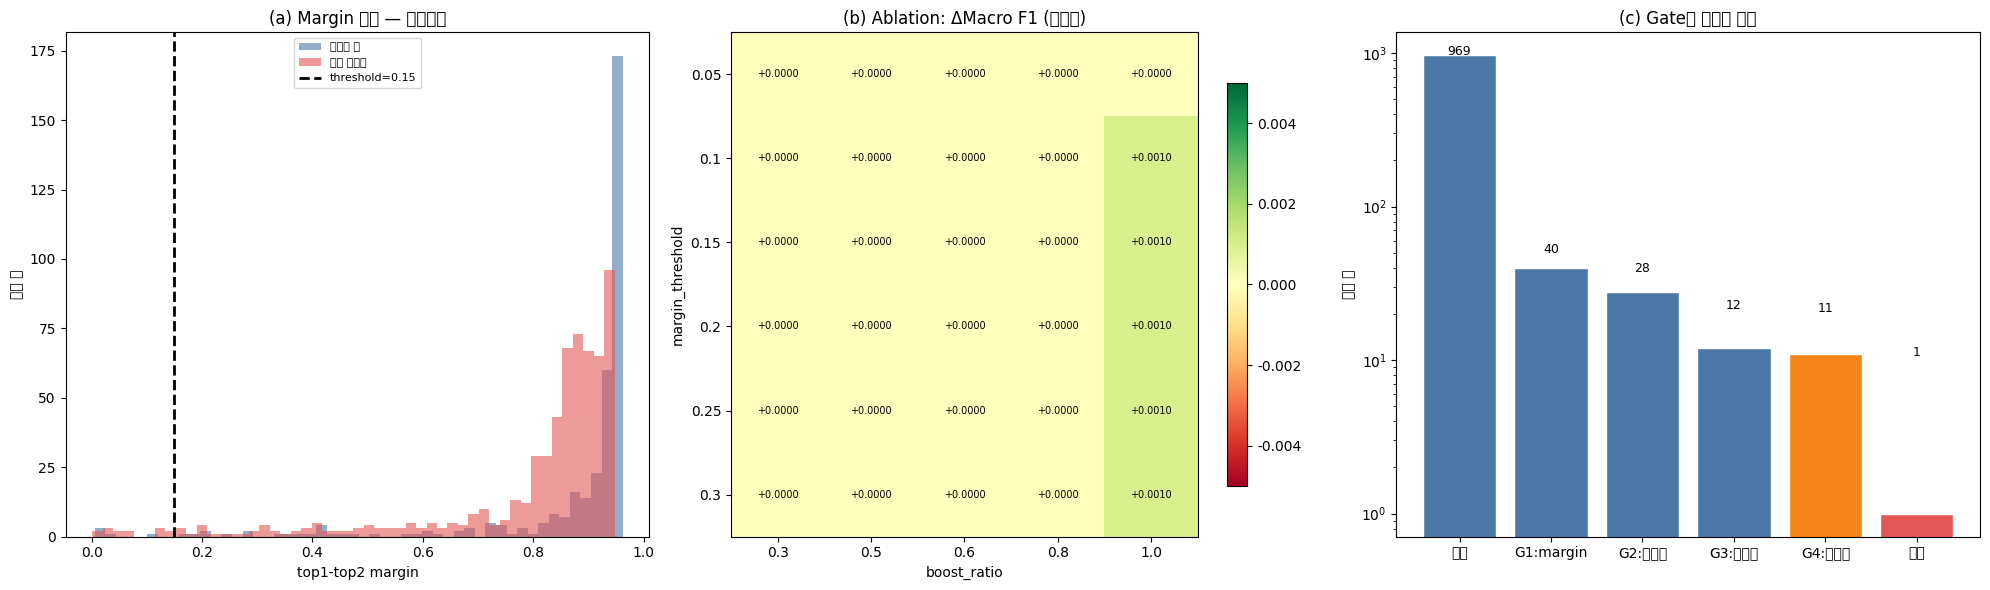

  → 저장: dktc_rule_postprocessing_v2.png


In [11]:
# ============================================================================
# 09. 시각화
# ============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
 
# --- 한글 폰트 ---
font_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
]
font_path = None
for fc in font_candidates:
    if os.path.exists(fc):
        font_path = fc
        break
if font_path:
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
 
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
 
# --- (a) Margin 분포 + 타겟 혼동축 비율 ---
ax = axes[0]
ax.hist(margins[~on_target_mask], bins=50, color="#4C78A8", alpha=0.6, label="비타겟 축")
ax.hist(margins[on_target_mask], bins=50, color="#E45756", alpha=0.6, label="타겟 혼동축")
ax.axvline(x=0.15, color="black", linestyle="--", linewidth=2, label="threshold=0.15")
ax.set_xlabel("top1-top2 margin")
ax.set_ylabel("샘플 수")
ax.set_title("(a) Margin 분포 — 혼동축별")
ax.legend(fontsize=8)
 
# --- (b) Ablation Heatmap ---
ax = axes[1]
pivot_data = pivot_f1.values
im = ax.imshow(pivot_data, cmap="RdYlGn", aspect="auto",
               vmin=-0.005, vmax=0.005)
ax.set_xticks(range(len(BOOST_RATIOS)))
ax.set_xticklabels([f"{v}" for v in BOOST_RATIOS])
ax.set_yticks(range(len(MARGIN_THRESHOLDS)))
ax.set_yticklabels([f"{v}" for v in MARGIN_THRESHOLDS])
ax.set_xlabel("boost_ratio")
ax.set_ylabel("margin_threshold")
ax.set_title("(b) Ablation: ΔMacro F1 (참고용)")
for i in range(len(MARGIN_THRESHOLDS)):
    for j in range(len(BOOST_RATIOS)):
        ax.text(j, i, f"{pivot_data[i, j]:+.4f}",
                ha="center", va="center", fontsize=7,
                color="white" if abs(pivot_data[i, j]) > 0.003 else "black")
fig.colorbar(im, ax=ax, shrink=0.8)
 
# --- (c) 파이프라인 Gate 통과 수 ---
ax = axes[2]
gate_names = ["전체", "G1:margin", "G2:혼동축", "G3:키워드", "G4:비동점", "변경"]
gate_counts = [
    adj_log["total_samples"],
    adj_log["n_boundary"],
    adj_log["n_on_target_axis"],
    adj_log["n_keyword_hit"],
    adj_log["n_top2_hit"],
    adj_log["n_changed"],
]
colors = ["#4C78A8"] * 4 + ["#F58518", "#E45756"]
ax.bar(gate_names, gate_counts, color=colors, edgecolor="white")
ax.set_ylabel("샘플 수")
ax.set_title("(c) Gate별 필터링 현황")
for i, v in enumerate(gate_counts):
    ax.text(i, v + max(gate_counts)*0.01, str(v), ha="center", fontsize=9)
ax.set_yscale("log")
 
plt.tight_layout()
plt.savefig("dktc_rule_postprocessing_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → 저장: dktc_rule_postprocessing_v2.png")

In [12]:
# ============================================================================
# 10. 커버리지 분석 v2 — Net Boost Advantage
# ============================================================================
# [검토의견 반영] v1의 coverage는 '정답 클래스 키워드 존재 여부'만 봤는데,
# 실제 후처리는 모든 클래스 규칙을 동시에 보므로 부족했음.
#
# v2는 '정답 클래스 boost가 오답 클래스 boost보다 우세한가'를 측정.
#   - net_advantage > 0: 후처리가 올바른 방향으로 작동
#   - net_advantage == 0: 효과 없음
#   - net_advantage < 0: 후처리가 오히려 악화 방향
 
wrong_mask = baseline_preds != val_labels
wrong_indices = np.where(wrong_mask)[0]
 
print(f"전체 오분류 {len(wrong_indices)}건에 대한 Net Boost Advantage 분석:\n")
 
# 타겟 혼동축 위의 오분류만 분석 (v2는 이것만 건드리므로)
analysis_results = []
 
for idx in wrong_indices:
    true_label = int(val_labels[idx])
    pred_label = int(baseline_preds[idx])
    text = val_texts[idx]
 
    # 이 오분류가 타겟 혼동축 위인지 확인
    confusion_pair = frozenset({true_label, pred_label})
    is_on_axis = confusion_pair in TARGET_CONFUSION_AXES
 
    # 키워드 매칭
    hits_true = count_keyword_hits(text, true_label)
    hits_pred = count_keyword_hits(text, pred_label)
    net_advantage = hits_true - hits_pred   # 양수 = 올바른 방향
 
    analysis_results.append({
        "idx": idx,
        "true_label": true_label,
        "pred_label": pred_label,
        "is_on_axis": is_on_axis,
        "hits_true": hits_true,
        "hits_pred": hits_pred,
        "net_advantage": net_advantage,
    })
 
df_coverage = pd.DataFrame(analysis_results)
 
# --- 타겟 축 위의 오분류 ---
on_axis_df = df_coverage[df_coverage["is_on_axis"]]
off_axis_df = df_coverage[~df_coverage["is_on_axis"]]
 
print(f"오분류 분류:")
print(f"  타겟 혼동축 위 : {len(on_axis_df)}건")
print(f"  비타겟 축      : {len(off_axis_df)}건 (v2는 이것을 건드리지 않음)")
 
if len(on_axis_df) > 0:
    # Net Boost Advantage 분포
    n_positive = (on_axis_df["net_advantage"] > 0).sum()   # 교정 가능
    n_zero = (on_axis_df["net_advantage"] == 0).sum()       # 효과 없음
    n_negative = (on_axis_df["net_advantage"] < 0).sum()    # 악화 가능
 
    print(f"\n타겟 축 오분류 Net Boost Advantage:")
    print(f"  교정 가능 (advantage > 0)  : {n_positive}건 ({n_positive/len(on_axis_df)*100:.1f}%)")
    print(f"  효과 없음 (advantage == 0) : {n_zero}건 ({n_zero/len(on_axis_df)*100:.1f}%)")
    print(f"  악화 위험 (advantage < 0)  : {n_negative}건 ({n_negative/len(on_axis_df)*100:.1f}%)")
 
    # 혼동축별 상세
    print(f"\n혼동축별 교정 가능률:")
    for axis in TARGET_CONFUSION_AXES:
        ids = sorted(axis)
        axis_name = f"{LABEL_NAMES[ids[0]]}↔{LABEL_NAMES[ids[1]]}"
        axis_df = on_axis_df[
            on_axis_df.apply(
                lambda r: frozenset({r['true_label'], r['pred_label']}) == axis, axis=1
            )
        ]
        if len(axis_df) > 0:
            n_pos = (axis_df["net_advantage"] > 0).sum()
            print(f"  {axis_name:20s}: {n_pos}/{len(axis_df)} "
                  f"({n_pos/len(axis_df)*100:.0f}%) 교정 가능")
 
# --- 악화 위험 샘플 확인 ---
bad_samples = on_axis_df[on_axis_df["net_advantage"] < 0]
if len(bad_samples) > 0:
    print(f"\n악화 위험 샘플 ({len(bad_samples)}건 — 키워드 개선 참고):")
    for _, row in bad_samples.head(5).iterrows():
        text_preview = val_texts[row["idx"]][:100].replace("\n", " ")
        print(f"  [{row['idx']:4d}] 정답={LABEL_NAMES[row['true_label']]:8s} "
              f"예측={LABEL_NAMES[row['pred_label']]:8s} "
              f"hits_true={row['hits_true']} hits_pred={row['hits_pred']} | {text_preview}...")

전체 오분류 68건에 대한 Net Boost Advantage 분석:

오분류 분류:
  타겟 혼동축 위 : 46건
  비타겟 축      : 22건 (v2는 이것을 건드리지 않음)

타겟 축 오분류 Net Boost Advantage:
  교정 가능 (advantage > 0)  : 3건 (6.5%)
  효과 없음 (advantage == 0) : 37건 (80.4%)
  악화 위험 (advantage < 0)  : 6건 (13.0%)

혼동축별 교정 가능률:
  협박↔갈취               : 1/14 (7%) 교정 가능
  갈취↔기타괴롭힘            : 2/24 (8%) 교정 가능
  직장내괴롭힘↔기타괴롭힘        : 0/8 (0%) 교정 가능

악화 위험 샘플 (6건 — 키워드 개선 참고):
  [ 127] 정답=기타괴롭힘    예측=갈취       hits_true=0 hits_pred=1 | 오 신발샀냐? [턴] 응. 전에 신던게 다 헤져서.부모님이 사주셨어. [턴] 니네 집 꽤 사나보다? 이런 신발도 잘 사주시고? [턴] 응.? 그런건 아닌데.그래도 신발은 오래 신는...
  [ 208] 정답=협박       예측=갈취       hits_true=0 hits_pred=2 | 김사장. 우리 그동안의 세월을 봐서 내가 많이 봐줬다. [턴] 한번만 더 시간을 주면 안되겠나? [턴] 김사장도 양심도 없지. 내가 땅파서 장사하나? [턴] 하지만 이자가 터무니 ...
  [ 262] 정답=협박       예측=갈취       hits_true=0 hits_pred=1 | 안녕하세요 [턴] 네 [턴] 혹시 이나연씨인가요? [턴] 네 맞아요 [턴] 왜그러시죠? [턴] 돈을 안갚으셨내요 [턴] 아 맞다 [턴] 내일까지 꼭 갚을게요 [턴] 오늘까지 갚으세...
  [ 595] 정답=협박       예측=갈취       hits_true=0 hits_pred=2 | 야 머하냐? [턴] 학원가려고. [턴] 돈 좀 있냐? [턴] 아니 없어. [턴]

In [13]:
# ============================================================================
# 11. Kaggle 제출 전략 — 후처리 포함/미포함 동시 제출
# ============================================================================
# [수정4] best 파라미터를 단일 validation에서 확정하지 않는다.
#
# 제출 전략:
#   제출 A: 원본 모델 (후처리 없음) — 기준선
#   제출 B: 보수적 후처리 (margin=0.15, boost_ratio=0.6)
#   제출 C: (선택) ablation에서 안정 구간의 다른 조합
#
# public LB 결과를 보고:
#   - B > A 이면 후처리 효과 있음 → private에도 B 사용 검토
#   - B <= A 이면 후처리 불필요 → A 유지
#   - B >> A (큰 차이)이면 후처리 과적합 가능성도 의심
 
def postprocess_for_submission(
    logits,
    texts,
    margin_threshold=0.15,
    boost_ratio=0.6,
):
    """
    Kaggle 제출용 후처리 함수.
 
    사용법:
        test_result = trainer.predict(test_dataset)
        test_logits = test_result.predictions
        # 제출 A: 후처리 없음
        preds_a = np.argmax(test_logits, axis=-1)
        # 제출 B: 후처리 적용
        preds_b = postprocess_for_submission(test_logits, test_texts)
    """
    adjusted_preds, _ = apply_rule_postprocessing_v2(
        logits=logits,
        texts=texts,
        margin_threshold=margin_threshold,
        boost_ratio=boost_ratio,
    )
    return adjusted_preds
 
 
# --- 현재 검증셋 기준 참고 성능 (확정 수치가 아님) ---
print("현재 검증셋 참고 성능 (⚠ 최종 확정 수치 아님):")
print(f"  원본 Macro F1     : {baseline_f1_macro:.4f}")
print(f"  후처리 Macro F1   : {adjusted_f1_macro:.4f}")
print(f"  Delta             : {adjusted_f1_macro - baseline_f1_macro:+.4f}")
print(f"  변경 건수          : {adj_log['n_changed']}")
print(f"\n⚠ 이 delta는 같은 validation에서 측정한 값입니다.")
print(f"  일반화 성능은 Kaggle public/private LB에서 확인해야 합니다.")
print(f"  반드시 후처리 없는 원본과 함께 제출하여 비교하세요.")

현재 검증셋 참고 성능 (⚠ 최종 확정 수치 아님):
  원본 Macro F1     : 0.9301
  후처리 Macro F1   : 0.9301
  Delta             : +0.0000
  변경 건수          : 1

⚠ 이 delta는 같은 validation에서 측정한 값입니다.
  일반화 성능은 Kaggle public/private LB에서 확인해야 합니다.
  반드시 후처리 없는 원본과 함께 제출하여 비교하세요.


In [14]:
# ============================================================================
# 12. 결과 저장
# ============================================================================
 
# --- Ablation CSV ---
df_ablation.to_csv("dktc_rule_postprocessing_v2_ablation.csv", index=False)
print("dktc_rule_postprocessing_v2_ablation.csv 저장 완료")
 
# --- 키워드 규칙 JSON ---
rules_export = {}
for class_name, patterns in KEYWORD_RULES.items():
    rules_export[class_name] = patterns
with open("dktc_keyword_rules_v2.json", "w", encoding="utf-8") as f:
    json.dump(rules_export, f, ensure_ascii=False, indent=2)
print("dktc_keyword_rules_v2.json 저장 완료")
 
# --- 후처리 설정 JSON ---
config_export = {
    "version": "v2",
    "target_confusion_axes": [
        [int(x) for x in sorted(axis)] for axis in TARGET_CONFUSION_AXES
    ],
    "default_margin_threshold": 0.15,
    "default_boost_ratio": 0.6,
    "baseline_macro_f1": float(baseline_f1_macro),
    "postprocessed_macro_f1_on_val": float(adjusted_f1_macro),
    "delta_f1_on_val": float(adjusted_f1_macro - baseline_f1_macro),
    "note": "delta는 동일 validation 기준 참고값. 일반화 성능은 LB에서 확인 필요.",
}
with open("dktc_postprocessing_config_v2.json", "w") as f:
    json.dump(config_export, f, indent=2)
print("dktc_postprocessing_config_v2.json 저장 완료")
 
# --- Net Boost Coverage CSV ---
df_coverage.to_csv("dktc_net_boost_coverage_v2.csv", index=False)
print("dktc_net_boost_coverage_v2.csv 저장 완료")
 
print(f"\n{'=' * 70}")
print(f"규칙 기반 후처리 v2 분석 완료")
print(f"  Baseline Macro F1          : {baseline_f1_macro:.4f}")
print(f"  Postprocessed (val 참고)    : {adjusted_f1_macro:.4f}")
print(f"  Delta (val 참고)            : {adjusted_f1_macro - baseline_f1_macro:+.4f}")
print(f"  Gate 통과율                 : {adj_log['n_top2_hit']}/{adj_log['total_samples']}")
print(f"  예측 변경                   : {adj_log['n_changed']}건")
print(f"{'=' * 70}")

dktc_rule_postprocessing_v2_ablation.csv 저장 완료
dktc_keyword_rules_v2.json 저장 완료
dktc_postprocessing_config_v2.json 저장 완료
dktc_net_boost_coverage_v2.csv 저장 완료

규칙 기반 후처리 v2 분석 완료
  Baseline Macro F1          : 0.9301
  Postprocessed (val 참고)    : 0.9301
  Delta (val 참고)            : +0.0000
  Gate 통과율                 : 11/969
  예측 변경                   : 1건
